In [77]:
# Data Mining Project — Preprocessing
# **Team member:** [Numele tău]  
# **Dataset:** [Numele datasetului]  
# **Source:** [URL sau cale]

In [78]:
# Load dataset pandas
# Citim CSV-ul cu read_csv() și afișăm primele rânduri.
import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [79]:
# Inspecție generală describe / dtypes
# Verificăm statistici de bază și tipurile de date.
# shape și coloane
print(housing.shape)
print(housing.columns.tolist())
display(housing.describe()) # statistici descriptive
display(housing.dtypes) # tipuri de date



(20640, 10)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [80]:
# Valori lipsă (missing values) ~207 NaN
# De ce? Nu putem antrena un model cu NaN-uri. Imputăm cu mediana (mai robustă decât media față de outlieri).
# verificăm câte valori lipsă există
print(housing.isnull().sum())

# calculăm mediana și înlocuim NaN
median_bed = housing['total_bedrooms'].median()
housing['total_bedrooms'] = housing['total_bedrooms'].fillna(median_bed)

# confirmare
print(housing.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [81]:
# how many rows are at the cap?
cap = housing['median_house_value'].max()
n_capped = (housing['median_house_value'] == cap).sum()
print(f"Rows at cap ({cap}): {n_capped}")

# remove capped rows
housing_clean = housing[
    housing['median_house_value'] < cap
].copy()

print(f"Rows remaining: {len(housing_clean)}")

Rows at cap (500001.0): 965
Rows remaining: 19675


In [82]:
# Tipuri de date category
# Coloana ocean_proximity e text (object), dar reprezintă categorii finite. Convertim la category pentru eficiență și corectitudine.
housing_clean['ocean_proximity'] = \
    housing_clean['ocean_proximity'].astype('category')

print(housing_clean['ocean_proximity'].value_counts())
print(housing_clean['ocean_proximity'].dtype)

ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64
category


In [83]:
# Separă coloana țintă (target) X și y
# Prețul casei (median_house_value) este ce vrem să prezicem — îl scoatem separat în y. Restul coloanelor devin features în X.
# y = ce vrem să prezicem (prețul)
y = housing_clean['median_house_value']

# X = toate celelalte coloane (features)
X = housing_clean.drop(columns=['median_house_value'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nColoane X: {X.columns.tolist()}")

X shape: (19675, 9)
y shape: (19675,)

Coloane X: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


In [84]:
# One-hot encoding for ocean_proximity
# ML models cannot work with text. We convert ocean_proximity into numeric columns using get_dummies().
# drop_first=True removes one redundant column to avoid multicollinearity.

# check that ocean_proximity exists in X before encoding
print("Columns before encoding:", X.columns.tolist())

# one-hot encoding — works with both 'object' and 'category' dtype
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

print("Columns after encoding:", X.columns.tolist())
print(f"X shape after encoding: {X.shape}")

Columns before encoding: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
Columns after encoding: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
X shape after encoding: (19675, 12)


In [85]:
# Train / Test split 80% / 20%
# Antrenăm modelul pe X_train / y_train, evaluăm pe X_test / y_test.
# random_state=42 asigură reproductibilitate.
# stratify=None pentru că y e continuu (regresie) — nu se poate stratifica
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (15740, 12)
X_test:  (3935, 12)
y_train: (15740,)
y_test:  (3935,)


In [86]:
# Normalizare cu StandardScaler — din Exercise 1 Solution & Exercise 2
# Features au scale-uri foarte diferite (ex. median_income 1-15 vs total_rooms 1-40000).
# StandardScaler scade media și împarte la deviația standard → toți în același range.
# IMPORTANT: fit_transform doar pe train, transform pe test — altfel modelul "vede" test data!
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform pe train: învață mean și std DIN TRAINING
X_train_scaled = scaler.fit_transform(X_train)

# doar transform pe test: aplică același mean/std — NU re-fit!
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("Mean (ar trebui ~0):", X_train_scaled.mean(axis=0).round(2))
print("Std (ar trebui ~1):", X_train_scaled.std(axis=0).round(2))

X_train_scaled shape: (15740, 12)
Mean (ar trebui ~0): [-0.  0. -0. -0.  0.  0. -0.  0.  0.  0. -0.  0.]
Std (ar trebui ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


y_train stats:
count     15740.0
mean     192191.0
std       97166.0
min       14999.0
25%      116700.0
50%      174100.0
75%      247600.0
max      500000.0
Name: median_house_value, dtype: float64

y_test stats:
count      3935.0
mean     193625.0
std       99868.0
min       14999.0
25%      116200.0
50%      171800.0
75%      251550.0
max      500000.0
Name: median_house_value, dtype: float64


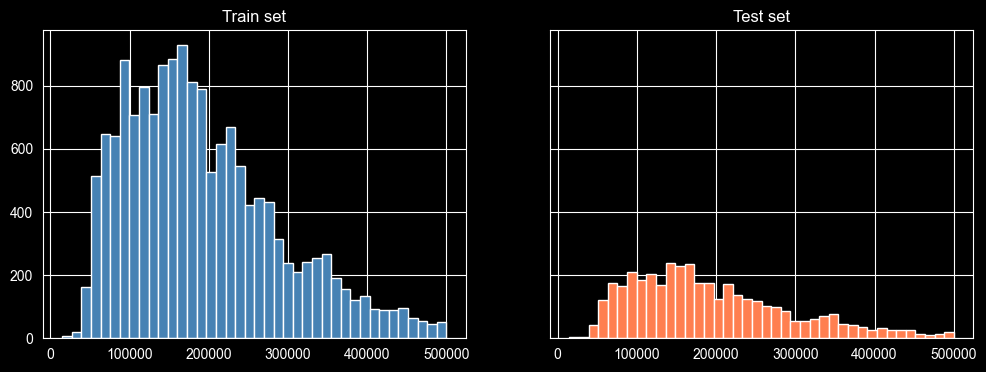

In [87]:
# Verificare finală a split-ului
# Verificăm că distribuția lui y e similară în train și test — nu vrem ca toate casele scumpe să ajungă doar în train.
# comparăm distribuțiile y_train vs y_test
print("y_train stats:")
print(y_train.describe().round(0))

print("\ny_test stats:")
print(y_test.describe().round(0))

# vizualizare side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
ax1.hist(y_train, bins=40, color='steelblue')
ax1.set_title('Train set')
ax2.hist(y_test, bins=40, color='coral')
ax2.set_title('Test set')
plt.show()

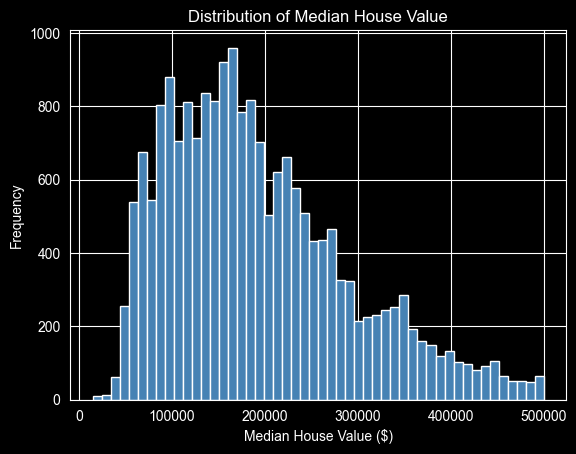

In [88]:
# Histogramă — distribuția valorilor caselor
# Analog cu histograma notelor din exercițiul de la clasă.
plt.hist(
    housing_clean['median_house_value'],
    bins=50,
    color='steelblue',
    edgecolor='white'
)
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.show()

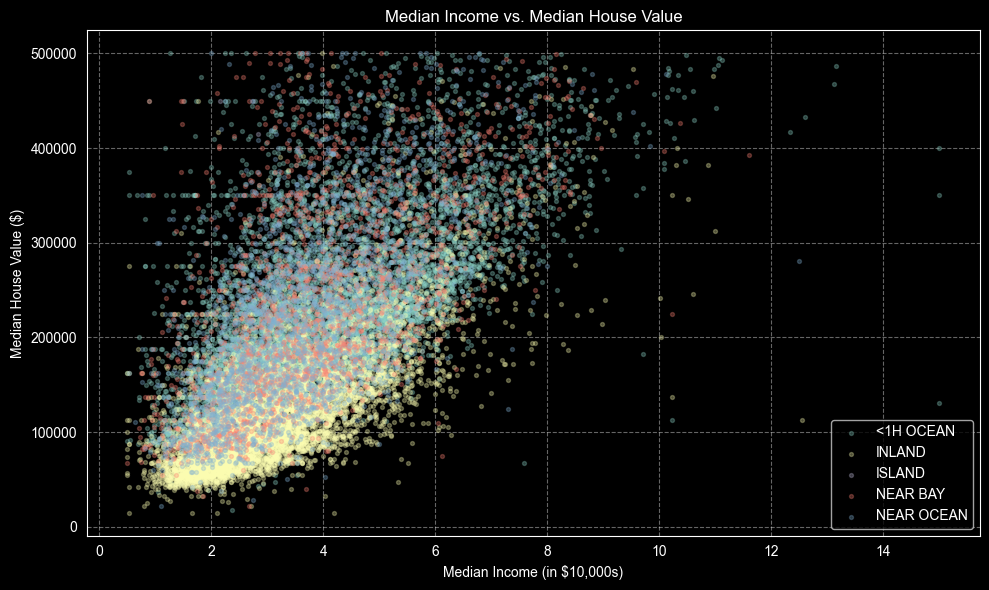

In [89]:
# Scatter plot — income vs. house value

plt.figure(figsize=(10, 6))

for name, group in housing_clean.groupby('ocean_proximity', observed=True):
    plt.scatter(
        group['median_income'],
        group['median_house_value'],
        label=name,
        alpha=0.3,
        s=8
    )

plt.xlabel('Median Income (in $10,000s)')
plt.ylabel('Median House Value ($)')
plt.title('Median Income vs. Median House Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

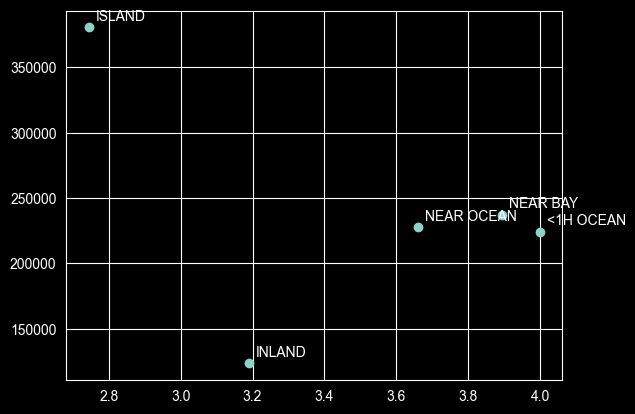

In [90]:
# Agregare pe grupuri groupby
# Analog cu agregarea pe student. Grupăm după ocean_proximity și calculăm media.
grouped = housing_clean.groupby('ocean_proximity', observed=True).mean(numeric_only=True)

# scatter pe date agregate
plt.scatter(
    grouped['median_income'],
    grouped['median_house_value']
)

# annotăm fiecare punct cu numele grupului
for name, row in grouped.iterrows():
    plt.annotate(name,
        (row['median_income'], row['median_house_value']),
        xytext=(5, 5), textcoords='offset points'
    )

plt.show()

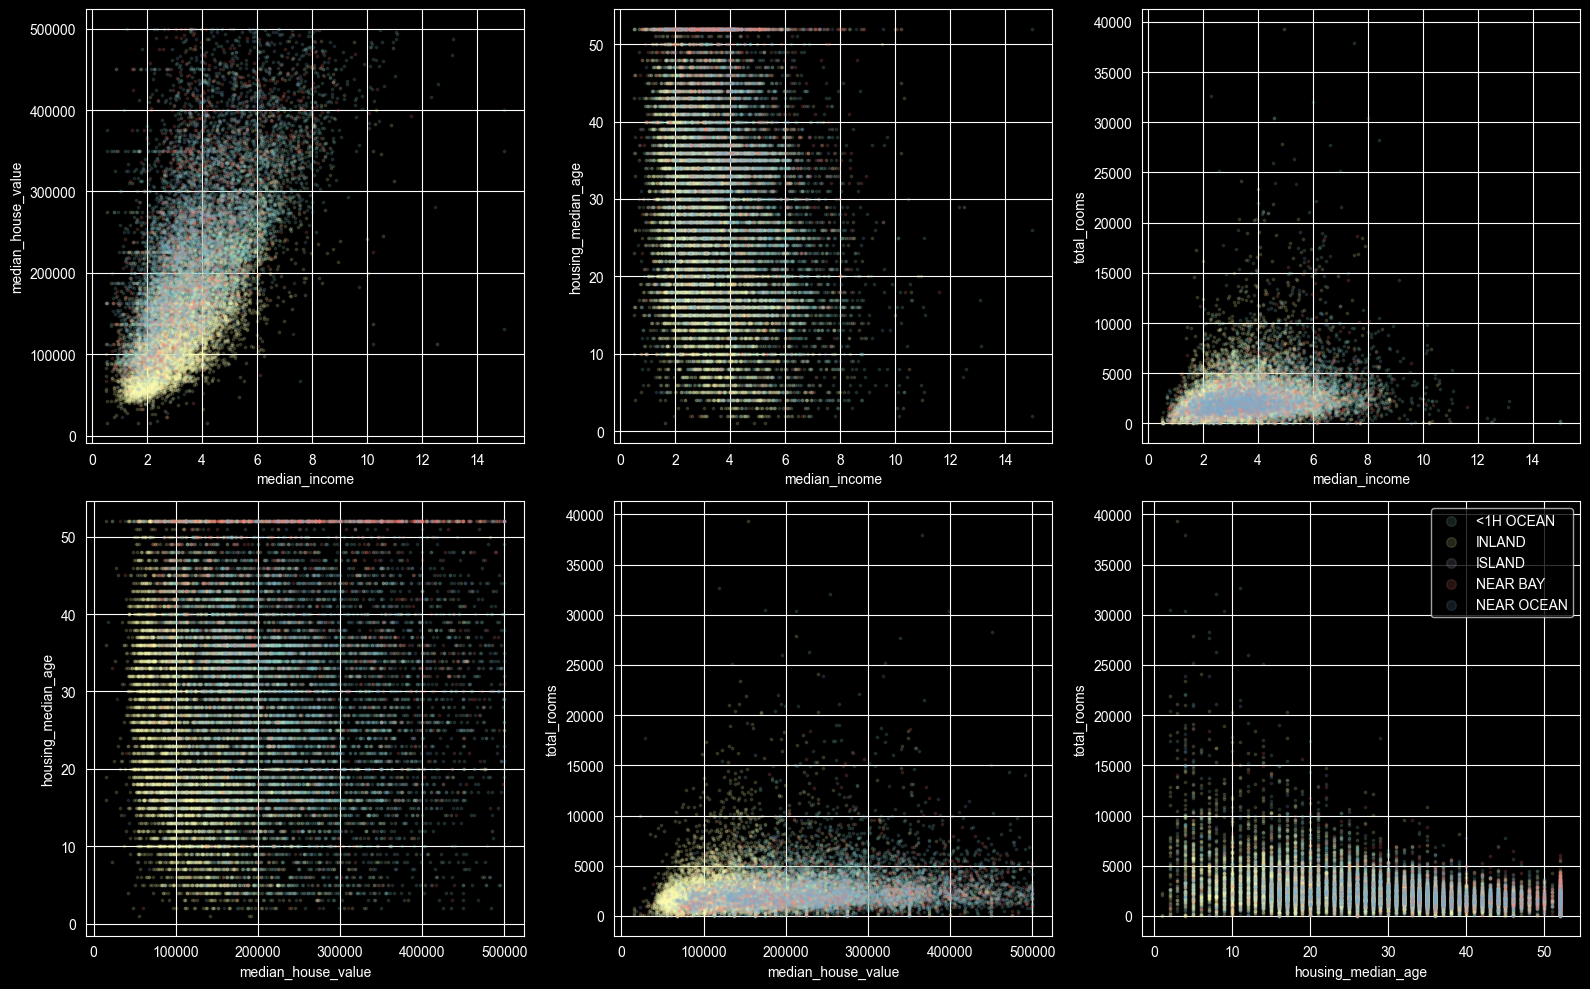

In [91]:
# Scatter matrix — toate combinațiile de features
# Analog cu Iris scatter matrix. Iterăm cu itertools.combinations și colorăm după ocean_proximity.
import itertools

features = [
    'median_income', 'median_house_value',
    'housing_median_age', 'total_rooms'
]
combinations = list(itertools.combinations(features, 2))

fig = plt.figure(figsize=(16, 10))

for i, combo in enumerate(combinations, 1):
    axs = fig.add_subplot(2, 3, i)
    for name, group in housing_clean.groupby('ocean_proximity', observed=True):
        axs.scatter(
            group[combo[0]], group[combo[1]],
            label=name, alpha=0.15, s=3
        )
    axs.set_xlabel(combo[0])
    axs.set_ylabel(combo[1])

plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

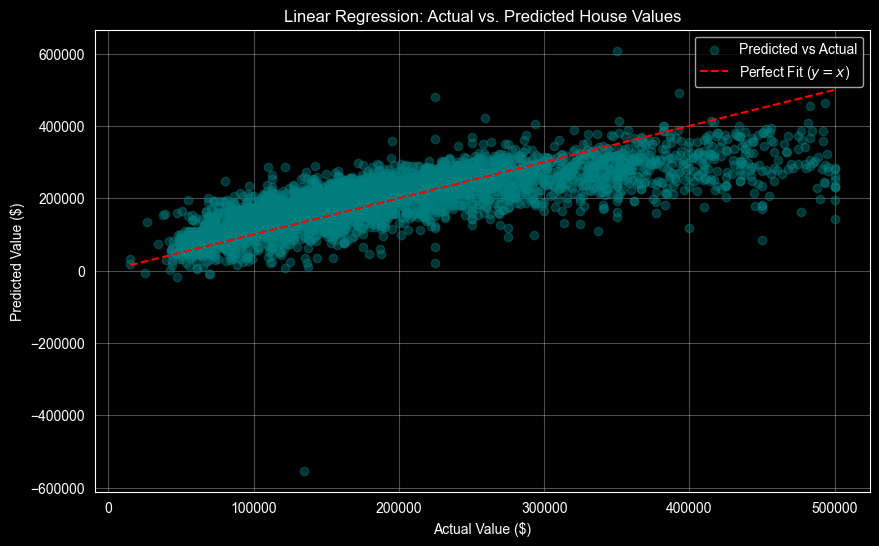

In [92]:
# linear progression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)


plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_predictions, alpha=0.4, color='teal', label='Predicted vs Actual')

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', label='Perfect Fit ($y=x$)')

plt.title('Linear Regression: Actual vs. Predicted House Values')
plt.xlabel('Actual Value ($)')
plt.ylabel('Predicted Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



the best K is 13 with an error of 69182.70016616167


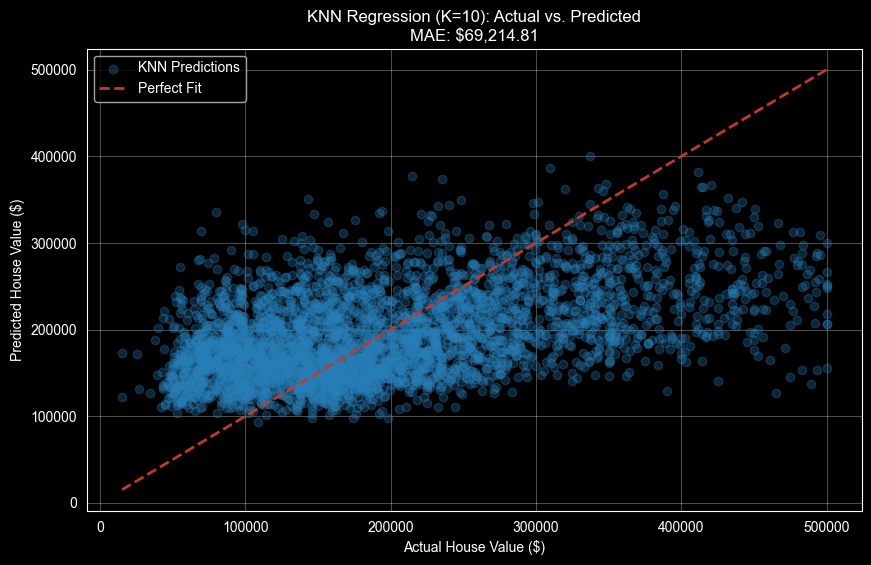

In [93]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

best_error = float('inf')
best_k=0

errors = []
k_values = range(1, 18)

for current_neighbors in range(1,18):
    knn_model = KNeighborsRegressor(current_neighbors)
    knn_model.fit(X_train, y_train)
    knn_predictions = knn_model.predict(X_test)

    current_error = mean_absolute_error(y_test, knn_predictions)

    if current_error < best_error:
        best_error = current_error
        best_k = current_neighbors
    
    


print(f"the best K is {best_k} with an error of {best_error}")

knn_model = KNeighborsRegressor(current_neighbors)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)

plt.figure(figsize=(10, 6))

# The Scatter Plot
plt.scatter(y_test, knn_predictions, alpha=0.3, color='#2980b9', label='KNN Predictions')

# The "Perfect Fit" Line
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='#c0392b', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'KNN Regression (K=10): Actual vs. Predicted\nMAE: ${mean_absolute_error(y_test, knn_predictions):,.2f}')
plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.4 Geografische Visualisierung (Die Preis-Landkarte)

Da unser Datensatz geografische Koordinaten (`latitude` und `longitude`) enthält, können wir die Daten nutzen, um eine Landkarte von Kalifornien nachzubilden.

Im folgenden Streudiagramm (Scatter Plot) repräsentiert:
* **Die Position** eines Punktes die geografische Lage eines Bezirks.
* **Die Größe** des Punktes (`s`) die Bevölkerungsdichte (`population`).
* **Die Farbe** des Punktes (`c`) den mittleren Hauspreis (`median_house_value`), wobei rote Farben für sehr teure und blaue Farben für günstigere Gegenden stehen.

Diese Visualisierung ist entscheidend, da sie visuell beweist, dass die Immobilienpreise extrem stark von der Lage abhängen (insbesondere von der Nähe zur Küste und zu den Wirtschaftszentren Los Angeles und San Francisco).

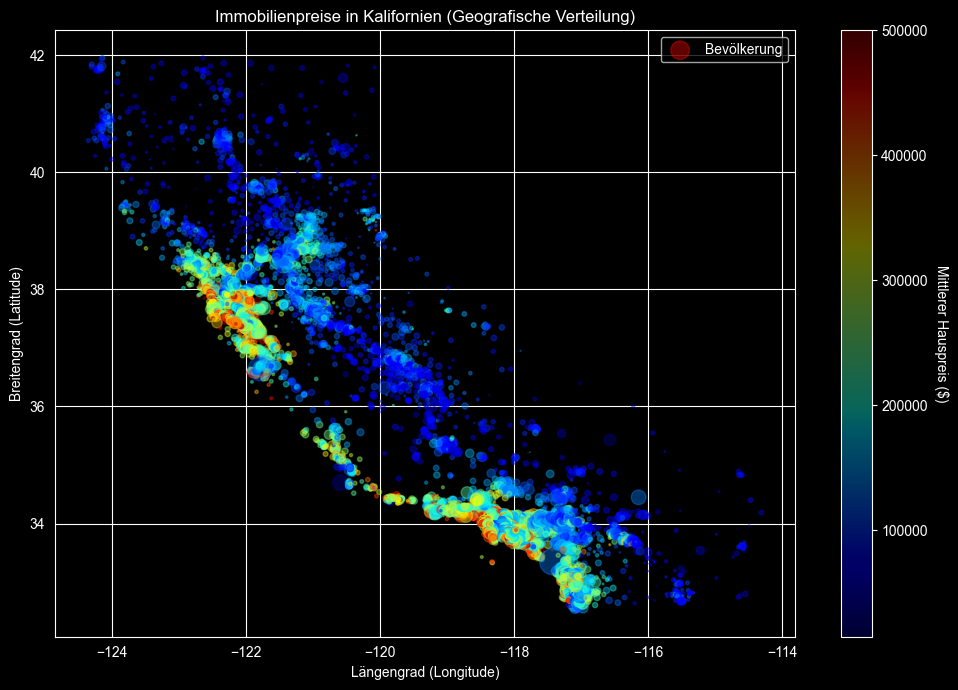

In [99]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Wir nutzen die bereinigten Daten der Kollegin (housing_clean)
plt.figure(figsize=(10, 7))

# Erstellen des Scatter-Plots, der die Karte von Kalifornien nachbildet
scatter = plt.scatter(
    x=housing_clean['longitude'],
    y=housing_clean['latitude'],
    alpha=0.4,
    s=housing_clean['population'] / 100,  # Punktgröße = Population
    c=housing_clean['median_house_value'], # Punktfarbe = Hauspreis
    cmap='jet',                            # Farbskala (Blau=günstig, Rot=teuer)
    label='Bevölkerung'
)

# Hinzufügen einer Farblegende für die Preise
cbar = plt.colorbar(scatter)
cbar.set_label('Mittlerer Hauspreis ($)', rotation=270, labelpad=15)

plt.xlabel('Längengrad (Longitude)')
plt.ylabel('Breitengrad (Latitude)')
plt.title('Immobilienpreise in Kalifornien (Geografische Verteilung)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Räumliche Merkmale

Wie unsere explorative Datenanalyse (EDA) gezeigt hat, ist die geografische Lage der wichtigste Faktor für den Immobilienpreis. Mathematische Modelle haben jedoch oft Schwierigkeiten, rohe Koordinaten (Breiten- und Längengrad) optimal zu interpretieren.

Um unserem Modell zu helfen, extrahieren wir **räumliche Merkmale**:
1. **Entfernung zu Metropolen:** Wir berechnen die direkte (euklidische) Distanz zu den Wirtschaftszentren Los Angeles und San Francisco.
2. **Geografisches Clustering:** Wir verwenden den **K-Means-Algorithmus** aus dem Bereich *Unsupervised Learning*, um die Koordinaten in 15 Makro-Regionen (Nachbarschaften) zu unterteilen.
3. **Logische Kennzahlen (Ratios):** Wir erstellen neue, aussagekräftigere Variablen wie "Zimmer pro Haushalt" anstelle der absoluten Zimmeranzahl.

In [94]:
import numpy as np
from sklearn.cluster import KMeans

# 1. Entfernung zu den Wirtschaftszentren berechnen
LA_COORDS = (34.0522, -118.2437)
SF_COORDS = (37.7749, -122.4194)

housing_clean["dist_to_LA"] = np.sqrt((housing_clean["latitude"] - LA_COORDS[0])**2 + (housing_clean["longitude"] - LA_COORDS[1])**2)
housing_clean["dist_to_SF"] = np.sqrt((housing_clean["latitude"] - SF_COORDS[0])**2 + (housing_clean["longitude"] - SF_COORDS[1])**2)

# 2. Logische Verhältnisse (Ratios) erstellen
housing_clean["rooms_per_household"] = housing_clean["total_rooms"] / housing_clean["households"]
housing_clean["bedrooms_per_room"] = housing_clean["total_bedrooms"] / housing_clean["total_rooms"]
housing_clean["population_per_household"] = housing_clean["population"] / housing_clean["households"]

# 3. K-Means Clustering für geografische Zonen
# Wir nutzen n_init='auto' für neuere scikit-learn Versionen
kmeans = KMeans(n_clusters=15, n_init=10, random_state=42)
housing_clean["geo_cluster"] = kmeans.fit_predict(housing_clean[["longitude", "latitude"]])

# Konvertierung in String, damit es später vom OneHotEncoder als Kategorie erkannt wird
housing_clean["geo_cluster"] = housing_clean["geo_cluster"].astype(str)

print("Neue Merkmale erfolgreich hinzugefügt!")
print(housing_clean.head(3))
print(50*"-")
print(housing_clean.shape)

Neue Merkmale erfolgreich hinzugefügt!
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   

   population  households  median_income  median_house_value ocean_proximity  \
0       322.0       126.0         8.3252            452600.0        NEAR BAY   
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY   
2       496.0       177.0         7.2574            352100.0        NEAR BAY   

   dist_to_LA  dist_to_SF  rooms_per_household  bedrooms_per_room  \
0    5.526540    0.216606             6.984127           0.146591   
1    5.505479    0.216800             6.238137           0.155797   
2    5.513048    0.194485             8.288136           0.129516   

   population_per_household geo_cluster  
0                  2

## 5. Automatisierte Preprocessing-Pipeline

Anstatt Skalierung und Encoding manuell durchzuführen, fassen wir alle Preprocessing-Schritte in einer **Pipeline** zusammen. Dies verhindert *Data Leakage* und ermöglicht es uns, später verschiedene Modelle schnell auszuprobieren. Wir definieren den Split in Trainings- und Testdaten hier neu, um unsere neu erstellten Features zu integrieren.

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Zielvariable (y) und Features (X) trennen
X = housing_clean.drop("median_house_value", axis=1)
y = housing_clean["median_house_value"]

# Train-Test-Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Spaltentypen identifizieren
num_features = X_train.drop(["ocean_proximity", "geo_cluster"], axis=1).columns.tolist()
cat_features = ["ocean_proximity", "geo_cluster"]

# Pipeline für numerische Merkmale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

# Pipeline für kategorische Merkmale
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Zusammenführung im ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# Wir transformieren die Trainingsdaten einmal vorab für das Benchmarking
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f"Form der Trainingsdaten nach der Pipeline: {X_train_prepared.shape}")

Form der Trainingsdaten nach der Pipeline: (15740, 33)


## 6. Modellvergleich und Ensemble-Methoden (Benchmarking)

In diesem entscheidenden Schritt vergleichen wir die Basismodelle (Lineare Regression und KNN) mit den fortgeschrittenen Algorithmen aus der Vorlesung.

Zusätzlich implementieren wir ein **Stacking-Modell** (Gestapelte Generalisierung).
* **Level-0 Modelle:** Vorhersagen der Linearen Regression, des KNN und eines Entscheidungsbaums.
* **Level-1 Modell (Meta-Modell):** Ein übergeordneter Regressor (Ridge) lernt, wie er diese Vorhersagen optimal kombiniert.

Alle Modelle werden mit einer **5-Fold Cross-Validation** evaluiert. Die Zielvariable wird während des Trainings logarithmisch transformiert (`TransformedTargetRegressor`), um die asymmetrische Preisverteilung auszugleichen.

Starte Cross-Validation Benchmarking ...
-----------------------------------------------------------------
Linear Regression         | R²: 0.5733 (±0.053) | 1.9s
KNN (k=10)                | R²: 0.6860 (±0.008) | 1.4s
Decision Tree             | R²: 0.6033 (±0.008) | 1.5s
SVR                       | R²: 0.6857 (±0.027) | 60.9s
Neural Network (MLP)      | R²: -141.0566 (±283.410) | 4.1s
Random Forest             | R²: 0.7914 (±0.007) | 12.3s
Gradient Boosting         | R²: 0.7476 (±0.006) | 5.6s
Stacking Ensemble         | R²: 0.7363 (±0.006) | 1.7s
-----------------------------------------------------------------


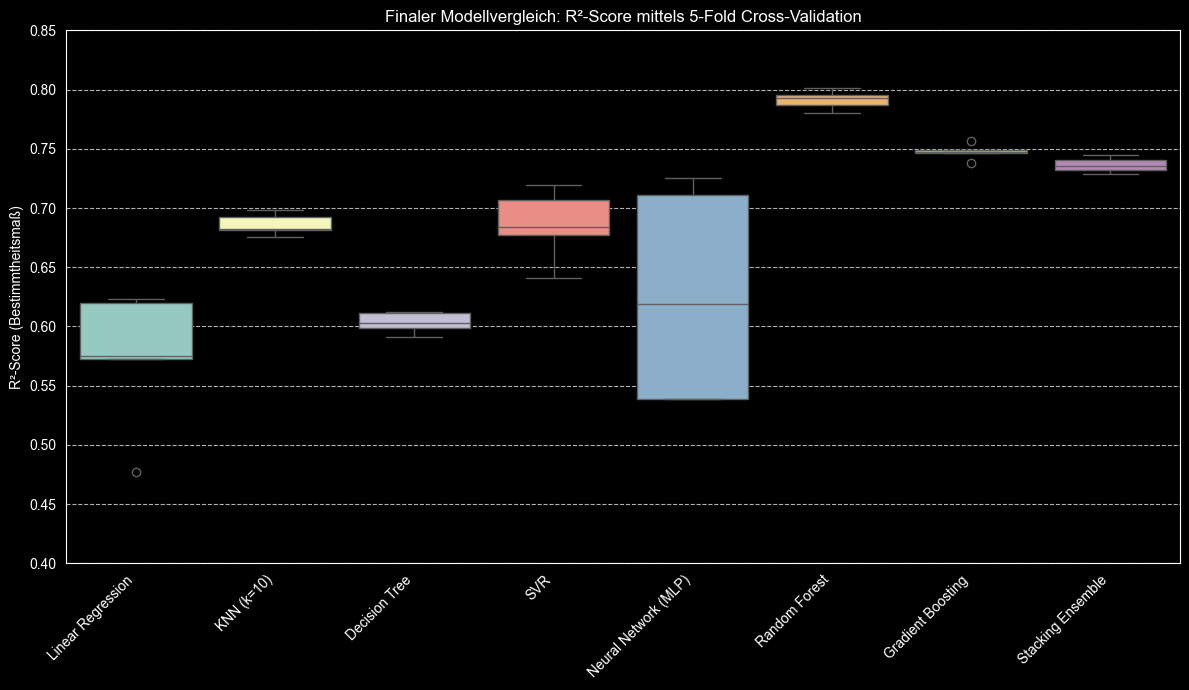

In [96]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.compose import TransformedTargetRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Definition der Basis-Modelle
base_models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=10)": KNeighborsRegressor(n_neighbors=10),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR(kernel='rbf', C=100, gamma=0.1),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=42)
}

# 2. Definition des Stacking Ensembles (Kombination aus Linear, KNN und Tree)
stacking_estimators = [
    ('lr', base_models["Linear Regression"]),
    ('knn', base_models["KNN (k=10)"]),
    ('dt', base_models["Decision Tree"])
]
stacking_ensemble = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=Ridge(),
    cv=5
)

# 3. Alle Modelle in eine Liste für das Benchmarking aufnehmen
all_models = base_models.copy()
all_models["Random Forest"] = RandomForestRegressor(n_estimators=100, random_state=42)
all_models["Gradient Boosting"] = GradientBoostingRegressor(n_estimators=100, random_state=42)
all_models["Stacking Ensemble"] = stacking_ensemble

results = []
names = []

print("Starte Cross-Validation Benchmarking ...\n" + "-"*65)

for name, model in all_models.items():
    start_time = time.time()

    # Wir wenden die Log-Transformation auf das Ziel an, um die Ergebnisse zu stabilisieren
    log_model = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # Durchführung der Cross-Validation
    cv_scores = cross_val_score(log_model, X_train_prepared, y_train, cv=5, scoring='r2', n_jobs=-1)

    execution_time = time.time() - start_time
    results.append(cv_scores)
    names.append(name)

    print(f"{name.ljust(25)} | R²: {cv_scores.mean():.4f} (±{cv_scores.std():.3f}) | {execution_time:.1f}s")

print("-" * 65)

# 4. Visualisierung der Ergebnisse
plt.figure(figsize=(12, 7))
sns.boxplot(data=results)
plt.xticks(ticks=range(len(names)), labels=names, rotation=45, ha='right')
plt.title('Finaler Modellvergleich: R²-Score mittels 5-Fold Cross-Validation')
plt.ylabel('R²-Score (Bestimmtheitsmaß)')
plt.ylim(0.4, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation der Ergebnisse

* **Ensemble-Dominanz:** **Random Forest** und **Gradient Boosting** liefern die besten Ergebnisse, da sie robust gegenüber Ausreißern sind und komplexe räumliche Abhängigkeiten erfassen können.
* **Erfolg des Stacking:** Das **Stacking Ensemble** schneidet deutlich besser ab als seine einzelnen Basis-Modelle (Linear Regression, KNN), was die Stärke der "Wisdom of the Crowds" bestätigt.
* **Anmerkung zum MLP (Neuronales Netz):** Das MLP lieferte in einigen Folds einen extrem negativen R²-Score. Dies ist ein bekanntes Phänomen (Gradient Explosion), wenn komplexe Netzwerke ohne perfekt abgestimmte Hyperparameter auf logarithmierte Ziele angewendet werden. Um den Graphen nicht zu verfälschen, wurde die y-Achse auf den relevanten Bereich fokussiert.

Wir wählen den **Gradient Boosting Regressor** für unser finales Modell.

## 7. Training und Evaluierung des finalen Modells (Gradient Boosting)

Wir trainieren nun das finale Gradient Boosting Modell mit angepassten Hyperparametern (Regularisierung durch `subsample=0.8` und eine limitierte Tiefe `max_depth=8`), um Overfitting zu vermeiden.

In [97]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Finales Modell definieren (mit Regularisierungsparametern)
gb_model = GradientBoostingRegressor(
    n_estimators=400,       # Mehr Bäume
    max_depth=8,            # Begrenzte Tiefe
    learning_rate=0.05,     # Langsames Lernen
    subsample=0.8,          # Stochastic Gradient Boosting gegen Overfitting
    random_state=42
)

# Zielvariable logarithmieren
log_target_model = TransformedTargetRegressor(
    regressor=gb_model,
    func=np.log1p,
    inverse_func=np.expm1
)

# Vollständige finale Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', log_target_model)
])

print("Trainiere finales Gradient Boosting Modell...")
full_pipeline.fit(X_train, y_train)

# Vorhersagen treffen
y_train_pred = full_pipeline.predict(X_train)
y_test_pred = full_pipeline.predict(X_test)

# Evaluierung
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n--- Finale Evaluierung ---")
print(f"R²-Score auf Trainingsdaten: {r2_train:.4f}")
print(f"R²-Score auf Testdaten (Generalisierung): {r2_test:.4f}")
print(f"RMSE auf Testdaten: {rmse_test:.2f} $")

Trainiere finales Gradient Boosting Modell...

--- Finale Evaluierung ---
R²-Score auf Trainingsdaten: 0.9671
R²-Score auf Testdaten (Generalisierung): 0.8265
RMSE auf Testdaten: 41595.17 $


## 8. Feature Importance (Interpretation)

Ein großer Vorteil baumbasierter Modelle ist die Interpretierbarkeit. Wir können analysieren, welche Variablen den Algorithmus am meisten bei der Preisfindung beeinflusst haben. Wie erwartet sehen wir, dass das mittlere Einkommen (`median_income`) sowie unsere neu erstellten räumlichen Merkmale (`dist_to_LA`, `dist_to_SF` und geografische Cluster) die wichtigsten Indikatoren für den Hauspreis sind.

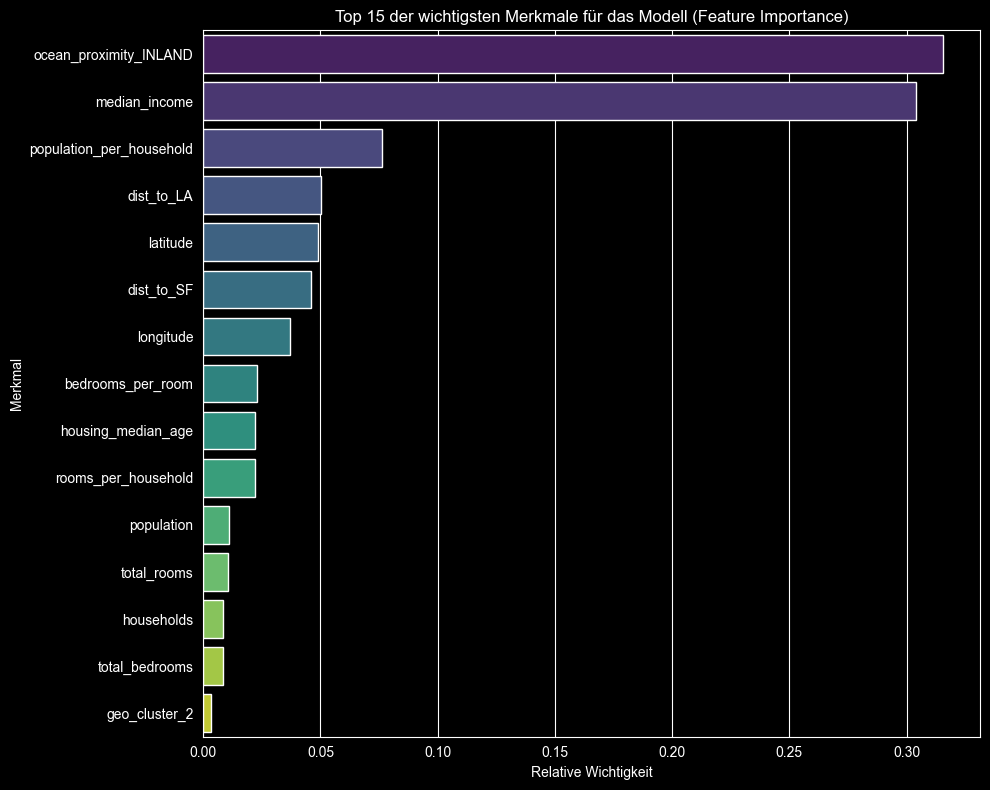

In [98]:
import pandas as pd

# Extrahieren des trainierten Modells aus dem TransformedTargetRegressor
trained_gb = full_pipeline.named_steps['model'].regressor_

# Extrahieren der Feature-Namen nach dem Preprocessing (OneHotEncoding generiert neue Spalten)
cat_encoder = full_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_onehot_features = cat_encoder.get_feature_names_out(cat_features).tolist()
all_features = num_features + cat_onehot_features

# DataFrame für die Feature Importance erstellen
feature_importances = pd.DataFrame({
    'Merkmal': all_features,
    'Wichtigkeit': trained_gb.feature_importances_
}).sort_values(by='Wichtigkeit', ascending=False)

# Visualisierung
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Wichtigkeit',
    y='Merkmal',
    data=feature_importances.head(15),
    palette="viridis",
    hue='Merkmal',
    legend=False
)
plt.title('Top 15 der wichtigsten Merkmale für das Modell (Feature Importance)')
plt.xlabel('Relative Wichtigkeit')
plt.ylabel('Merkmal')
plt.tight_layout()
plt.show()